**Credit Card Fraud Detection System**

Importing Required Libraries

In [18]:
!pip install -q imbalanced-learn xgboost shap

In [19]:
# General Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Preprocessing and Utilities
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Feature Selection
from collections import Counter

# Handling Imbalance
from imblearn.over_sampling import SMOTE

# Model Explainability
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

Loading and Exploring the Dataset

In [20]:
# Loading the dataset
df = pd.read_csv('creditcard.csv')

# Quick overview
print("Dataset Overview:")
df.head()

Dataset Overview:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Data Preprocessing

In [21]:
# Feature scaling for 'Amount'
df['Amount'] = StandardScaler().fit_transform(df[['Amount']])
df.drop(['Time'], axis=1, inplace=True)

# Separating features and target
X = df.drop('Class', axis=1)
y = df['Class']

Feature Selection

In [22]:
# Remove NaN in y
data = pd.concat([X, y], axis=1).dropna(subset=[y.name])
X = data.drop(columns=[y.name])
y = data[y.name].astype(int)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train model
xgb_model = XGBClassifier()
xgb_model.fit(X_scaled, y)

# Feature importance
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Top 15 features
top_features = feature_importance_df['Feature'].head(15).tolist()
print("Top 15 Selected Features:", top_features)

# Filter
X_selected = X_scaled[top_features]

Top 15 Selected Features: ['V14', 'V17', 'V10', 'V11', 'V9', 'V18', 'V5', 'V4', 'V8', 'V28', 'V16', 'V27', 'V26', 'V7', 'V12']


Exploratory Data Analysis before SMOTE

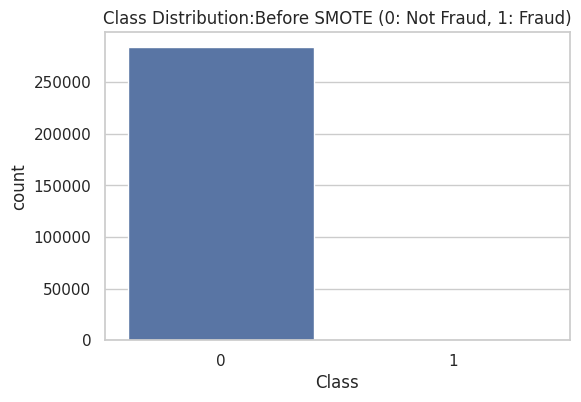

Dataset shape: Counter({0: 284315, 1: 492})
Total transactions: 284807
Non-Fraudulent transactions:  284315
Fraudulent transactions:  492
Percentage of Fraudulent transactions: 0.1727%


In [23]:
# Checking dataset balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution:Before SMOTE (0: Not Fraud, 1: Fraud)')
plt.savefig('class_distribution_before_smote.png')
plt.show()

print("Dataset shape:", Counter(y))
print("Total transactions:", X.shape[0])
print("Non-Fraudulent transactions: ", (df['Class'] == 0).sum())
print("Fraudulent transactions: ", df['Class'].sum())
print("Percentage of Fraudulent transactions: {:.4f}%".format((df['Class'].sum() / len(df)) * 100))

Using SMOTE

In [24]:
# Handling class imbalance using SMOTE
X_res, y_res = SMOTE().fit_resample(X, y)

Exploratory Data Analysis after SMOTE

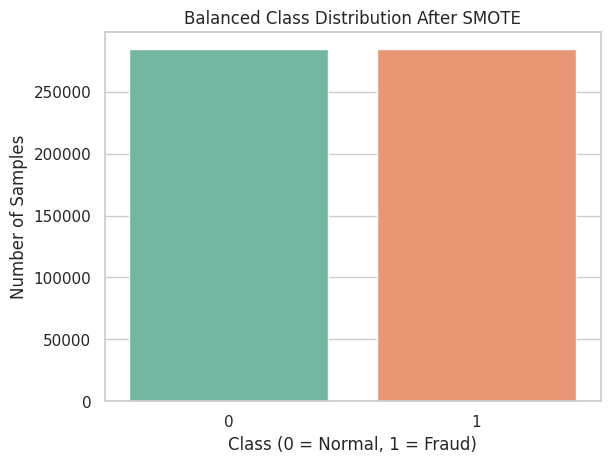

Original dataset shape: Counter({0: 284315, 1: 492})
After SMOTE dataset shape: Counter({0: 284315, 1: 284315})

After SMOTE:
Total transactions: 568630
Non-Fraudulent transactions: 284315
Fraudulent transactions: 284315
Percentage of Fraudulent transactions: 50.0000%


In [25]:
# Showing class distribution after SMOTE
sns.countplot(x=y_res, palette="Set2")
plt.title("Balanced Class Distribution After SMOTE")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Samples")
plt.savefig('class_distribution_after_smote.png')
plt.show()

print("Original dataset shape:", Counter(y))
print("After SMOTE dataset shape:", Counter(y_res))
print()
print("After SMOTE:")
print("Total transactions:", X_res.shape[0])
print("Non-Fraudulent transactions:", (y_res == 0).sum())
print("Fraudulent transactions:", (y_res == 1).sum())  # Corrected line
print("Percentage of Fraudulent transactions: {:.4f}%".format((y_res.sum() / len(y_res)) * 100))

Splitting Training and Testing Data

In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

Logistic Regression

Sample Predictions: [0 1 0 1 1 0 1 1 0 1]
Logistic Regression Evaluation:
Accuracy  : 0.9460
Precision : 0.9738
Recall    : 0.9168
F1 Score  : 0.9445
ROC-AUC   : 0.9890



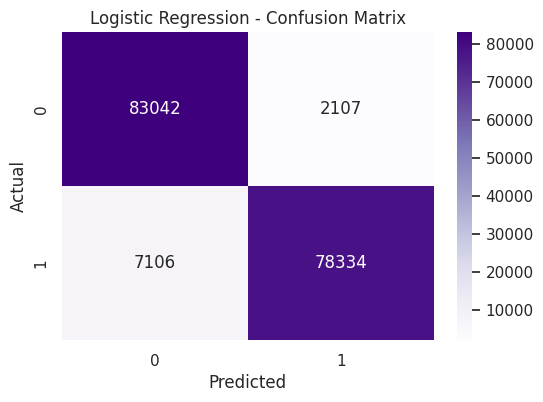

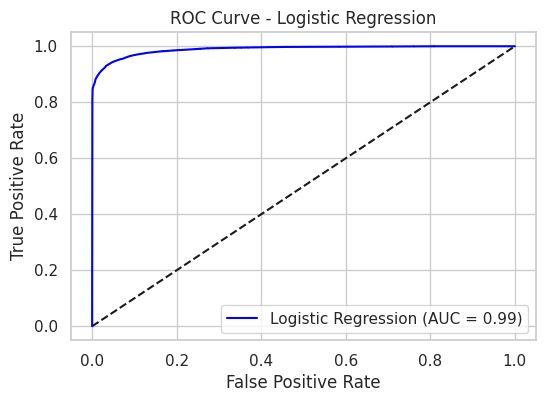

In [27]:
# Training Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]  # For ROC-AUC

# Printing predictions
print("Sample Predictions:", y_pred_lr[:10])

# Evaluation Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Printing Evaluation Metrics
print("Logistic Regression Evaluation:")
print(f"Accuracy  : {acc_lr:.4f}")
print(f"Precision : {prec_lr:.4f}")
print(f"Recall    : {rec_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {auc_lr:.4f}")
print()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('confusion_matrix_logistic_regression.png')
plt.show()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.savefig('roc_curve_logistic_regression.png')
plt.show()

Random Forest Classifier

Sample Predictions: [1 1 0 1 1 0 1 1 0 1]
Random Forest Evaluation:
Accuracy  : 0.9999
Precision : 0.9997
Recall    : 1.0000
F1 Score  : 0.9999
ROC-AUC   : 1.0000


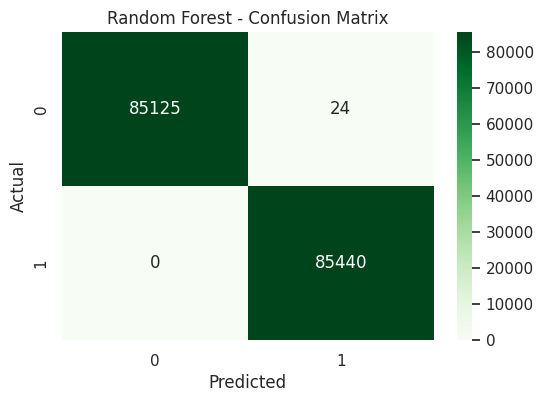

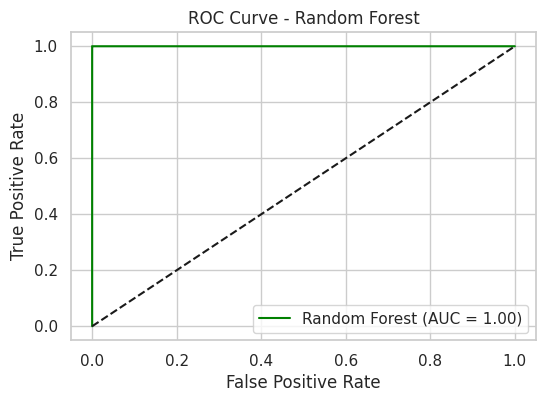

In [28]:
# Training Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]  # For ROC-AUC

# Printing predictions
print("Sample Predictions:", y_pred_rf[:10])

# Evaluation Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Printing Evaluation Metrics
print("Random Forest Evaluation:")
print(f"Accuracy  : {acc_rf:.4f}")
print(f"Precision : {prec_rf:.4f}")
print(f"Recall    : {rec_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {auc_rf:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('confusion_matrix_random_forest.png')
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.savefig('roc_curve_random_forest.png')
plt.show()

XGBoost Classifier

Sample Predictions: [1 1 0 1 1 0 1 1 0 1]
XGBoost Evaluation:
Accuracy  : 0.9997
Precision : 0.9994
Recall    : 1.0000
F1 Score  : 0.9997
ROC-AUC   : 1.0000


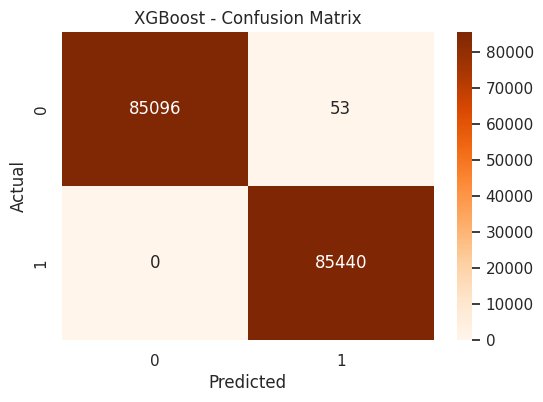

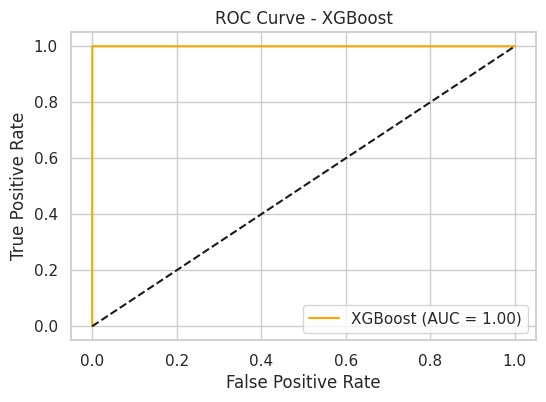

In [29]:
# Training XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]  # For ROC-AUC

# Printing predictions
print("Sample Predictions:", y_pred_xgb[:10])

# Evaluation Metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# Printing Evaluation Metrics
print("XGBoost Evaluation:")
print(f"Accuracy  : {acc_xgb:.4f}")
print(f"Precision : {prec_xgb:.4f}")
print(f"Recall    : {rec_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")
print(f"ROC-AUC   : {auc_xgb:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('confusion_matrix_xgboost.png')
plt.show()

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.savefig('roc_curve_xgboost.png')
plt.show()

Model Comparison

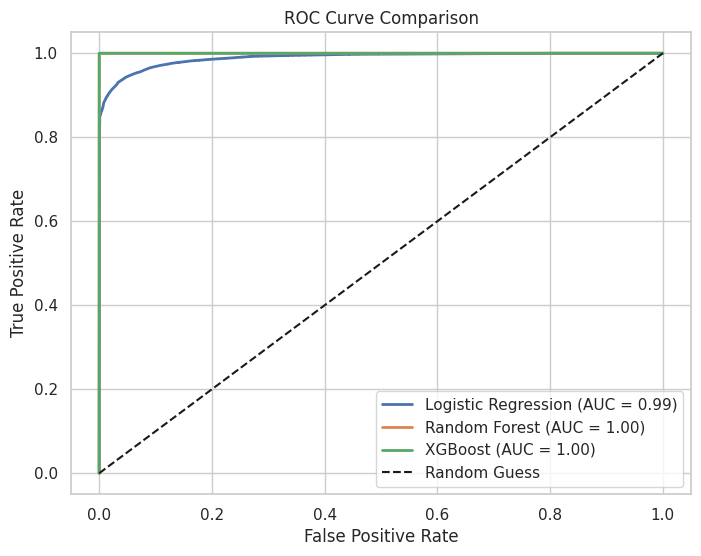

In [30]:
# Plotting all ROC curves together
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.savefig('roc_curve_comparison.png')
plt.show()

Comparison Table of All Metrics

In [31]:
# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb],
    'Precision': [prec_lr, prec_rf, prec_xgb],
    'Recall': [rec_lr, rec_rf, rec_xgb],
    'F1 Score': [f1_lr, f1_rf, f1_xgb],
    'ROC-AUC': [auc_lr, auc_rf, auc_xgb]
})

# Round for better presentation
comparison_df = comparison_df.round(4)

# Display the table
print("Model Performance Comparison:")
display(comparison_df.style.background_gradient(cmap='YlGnBu'))


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.946000,0.973800,0.916800,0.944500,0.989000
1,Random Forest,0.999900,0.999700,1.000000,0.999900,1.000000
2,XGBoost,0.999700,0.999400,1.000000,0.999700,1.000000


Model Explainability with SHAP

100%|===================| 170521/170589 [20:16<00:00]       

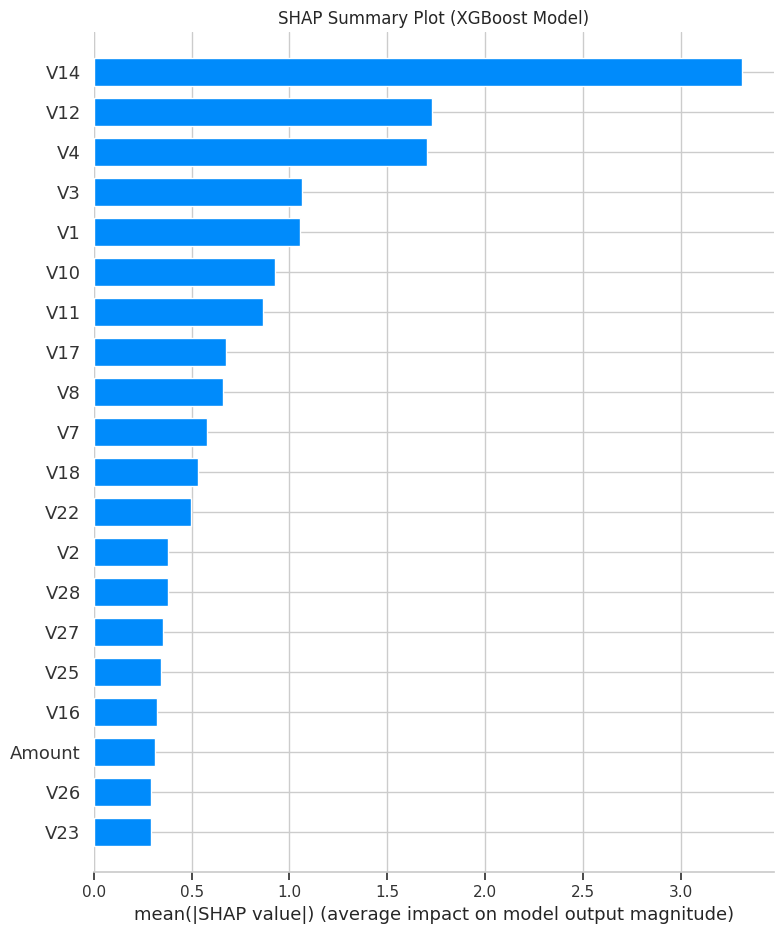

<Figure size 640x480 with 0 Axes>

In [32]:
# SHAP - Explainability for XGBoost
explainer = shap.Explainer(xgb_model, X_test, feature_names=X.columns)
shap_values = explainer(X_test)

# Summary Plot (Feature Importance)
plt.title("SHAP Summary Plot (XGBoost Model)")
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.savefig('shap_summary_plot.png')
plt.show()
